# Neural Collapse in a Tiny PyTorch Example

This notebook trains a **small MLP classifier** on a simple synthetic dataset and shows several hallmark neural-collapse behaviors in the final phase of training:

1. **Within-class collapse**: features from the same class become tightly clustered.
2. **Between-class symmetry**: class means become more evenly separated.
3. **Classifier-feature alignment**: the last-layer weights align with centered class means.

The example is intentionally small and pedagogical rather than state-of-the-art.

## Imports

In [1]:
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cpu


## Reproducibility

In [2]:
def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)

## Synthetic dataset

We generate a balanced $K$-class dataset in $\mathbb{R}^2$ from well-separated Gaussian blobs.
This keeps visualization simple while still allowing us to inspect the learned feature geometry.

In [3]:
def make_blobs(
    num_classes: int = 4,
    points_per_class: int = 300,
    radius: float = 6.0,
    noise: float = 0.8,
):
    xs = []
    ys = []
    for k in range(num_classes):
        angle = 2 * math.pi * k / num_classes
        center = torch.tensor([radius * math.cos(angle), radius * math.sin(angle)])
        xk = center + noise * torch.randn(points_per_class, 2)
        yk = torch.full((points_per_class,), k, dtype=torch.long)
        xs.append(xk)
        ys.append(yk)
    X = torch.cat(xs, dim=0)
    y = torch.cat(ys, dim=0)
    return X, y

K = 4
X, y = make_blobs(num_classes=K, points_per_class=400, radius=5.0, noise=0.4)

perm = torch.randperm(len(X))
X = X[perm]
y = y[perm]

n_train = int(0.8 * len(X))
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=512, shuffle=False)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

train: torch.Size([1280, 2]) torch.Size([1280])
test : torch.Size([320, 2]) torch.Size([320])


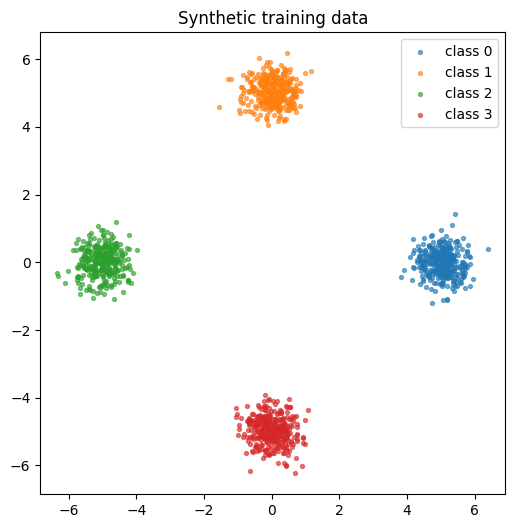

In [4]:
plt.figure(figsize=(6, 6))
for k in range(K):
    mask = (y_train == k)
    plt.scatter(X_train[mask, 0], X_train[mask, 1], s=8, alpha=0.6, label=f"class {k}")
plt.axis("equal")
plt.legend()
plt.title("Synthetic training data")
plt.show()

## Model

We use a network of the form

$$
x \mapsto f_\\theta(x) \in \mathbb{R}^d, \qquad
z \mapsto W z + b \in \mathbb{R}^K,
$$

where $f_\theta$ is the learned feature map and the final affine layer is the classifier.

In [5]:
class TinyNCNet(nn.Module):
    def __init__(self, in_dim: int = 2, hidden: int = 64, feat_dim: int = 3, num_classes: int = 4):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, feat_dim),
        )
        self.classifier = nn.Linear(feat_dim, num_classes, bias=True)

    def features(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.features(x)
        return self.classifier(h)

model = TinyNCNet(in_dim=2, hidden=64, feat_dim=3, num_classes=K).to(device)
print(model)

TinyNCNet(
  (backbone): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
  (classifier): Linear(in_features=3, out_features=4, bias=True)
)


## Helper functions for neural-collapse diagnostics

In [6]:
@torch.no_grad()
def collect_features(model: nn.Module, X: torch.Tensor, y: torch.Tensor, batch_size: int = 512):
    model.eval()
    feats = []
    logits = []
    ys = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yb = y[i:i+batch_size].to(device)
        hb = model.features(xb)
        zb = model.classifier(hb)
        feats.append(hb.cpu())
        logits.append(zb.cpu())
        ys.append(yb.cpu())
    H = torch.cat(feats, dim=0)
    Z = torch.cat(logits, dim=0)
    Y = torch.cat(ys, dim=0)
    return H, Z, Y

@torch.no_grad()
def accuracy(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return correct / total

@torch.no_grad()
def class_means(H: torch.Tensor, y: torch.Tensor, num_classes: int):
    means = []
    for k in range(num_classes):
        means.append(H[y == k].mean(dim=0))
    return torch.stack(means, dim=0)

@torch.no_grad()
def within_class_variance(H: torch.Tensor, y: torch.Tensor, means: torch.Tensor):
    vals = []
    for k in range(means.shape[0]):
        Hk = H[y == k]
        vals.append(((Hk - means[k]) ** 2).sum(dim=1).mean())
    return torch.stack(vals).mean().item()

@torch.no_grad()
def mean_pairwise_cosine(means: torch.Tensor):
    M = F.normalize(means, dim=1)
    G = M @ M.T
    K = G.shape[0]
    mask = ~torch.eye(K, dtype=torch.bool)
    return G[mask].mean().item(), G

@torch.no_grad()
def classifier_mean_alignment(model: nn.Module, means: torch.Tensor):
    W = model.classifier.weight.detach().cpu()
    centered_means = means - means.mean(dim=0, keepdim=True)
    Wn = F.normalize(W, dim=1)
    Mn = F.normalize(centered_means, dim=1)
    cos = (Wn * Mn).sum(dim=1)
    return cos.mean().item(), cos, W, centered_means

@torch.no_grad()
def nc_metrics(model: nn.Module, X: torch.Tensor, y: torch.Tensor, num_classes: int):
    H, Z, Y = collect_features(model, X, y)
    means = class_means(H, Y, num_classes)
    wcv = within_class_variance(H, Y, means)
    mean_cos, gram = mean_pairwise_cosine(means - means.mean(dim=0, keepdim=True))
    align_mean, align_vec, W, centered_means = classifier_mean_alignment(model, means)
    return {
        "features": H,
        "logits": Z,
        "labels": Y,
        "means": means,
        "within_class_variance": wcv,
        "pairwise_mean_cosine": mean_cos,
        "gram": gram,
        "alignment_mean_cosine": align_mean,
        "alignment_per_class": align_vec,
        "W": W,
        "centered_means": centered_means,
    }

## Training

We train for a fairly long time after accuracy saturates so that the final-stage geometry has time to sharpen.

In [7]:
@dataclass
class TrainConfig:
    epochs: int = 1000
    lr: float = 1e-2
    weight_decay: float = 1e-4

cfg = TrainConfig()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=cfg.lr,
    momentum=0.9,
    weight_decay=cfg.weight_decay,
)

history = {
    "epoch": [],
    "train_acc": [],
    "test_acc": [],
    "loss": [],
    "within_class_variance": [],
    "pairwise_mean_cosine": [],
    "alignment_mean_cosine": [],
}

for epoch in range(1, cfg.epochs + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.shape[0]
        n_seen += xb.shape[0]

    train_acc = accuracy(model, train_loader)
    test_acc = accuracy(model, test_loader)
    metrics = nc_metrics(model, X_train, y_train, K)

    history["epoch"].append(epoch)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["loss"].append(running_loss / n_seen)
    history["within_class_variance"].append(metrics["within_class_variance"])
    history["pairwise_mean_cosine"].append(metrics["pairwise_mean_cosine"])
    history["alignment_mean_cosine"].append(metrics["alignment_mean_cosine"])

    if epoch <= 10 or epoch % 100 == 0:
        print(
            f"epoch={epoch:3d} "
            f"loss={history['loss'][-1]:.4f} "
            f"train_acc={train_acc:.3f} "
            f"test_acc={test_acc:.3f} "
            f"wcv={metrics['within_class_variance']:.4f} "
            f"align={metrics['alignment_mean_cosine']:.4f}"
        )

epoch=  1 loss=1.3807 train_acc=0.346 test_acc=0.344 wcv=0.0107 align=0.4682
epoch=  2 loss=1.0677 train_acc=1.000 test_acc=1.000 wcv=0.0610 align=0.6301
epoch=  3 loss=0.4387 train_acc=1.000 test_acc=1.000 wcv=0.2773 align=0.8380
epoch=  4 loss=0.0532 train_acc=1.000 test_acc=1.000 wcv=0.5732 align=0.8984
epoch=  5 loss=0.0050 train_acc=1.000 test_acc=1.000 wcv=0.7613 align=0.9115
epoch=  6 loss=0.0019 train_acc=1.000 test_acc=1.000 wcv=0.8506 align=0.9162
epoch=  7 loss=0.0012 train_acc=1.000 test_acc=1.000 wcv=0.8907 align=0.9185
epoch=  8 loss=0.0010 train_acc=1.000 test_acc=1.000 wcv=0.9104 align=0.9198
epoch=  9 loss=0.0008 train_acc=1.000 test_acc=1.000 wcv=0.9217 align=0.9207
epoch= 10 loss=0.0007 train_acc=1.000 test_acc=1.000 wcv=0.9295 align=0.9213
epoch=100 loss=0.0001 train_acc=1.000 test_acc=1.000 wcv=1.0958 align=0.9331
epoch=200 loss=0.0001 train_acc=1.000 test_acc=1.000 wcv=1.1312 align=0.9377
epoch=300 loss=0.0001 train_acc=1.000 test_acc=1.000 wcv=1.1349 align=0.9406

## Training curves

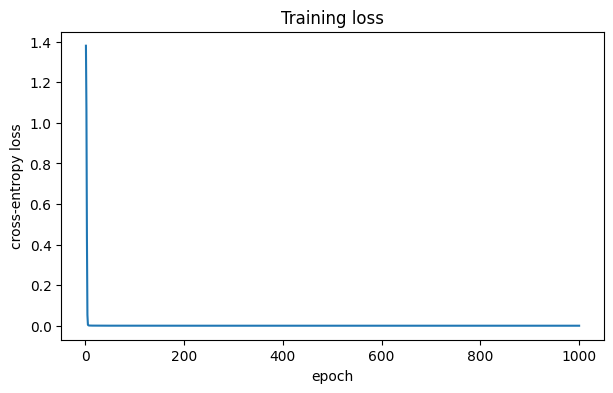

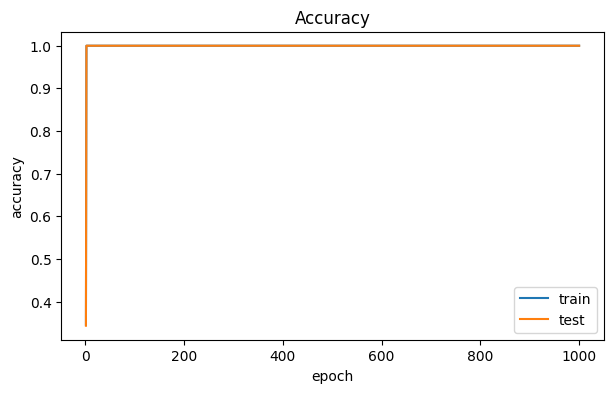

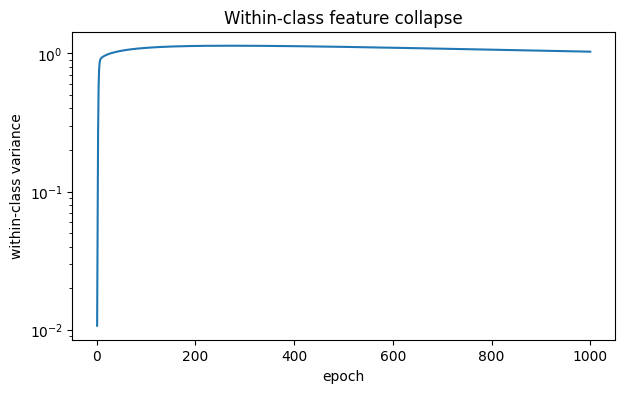

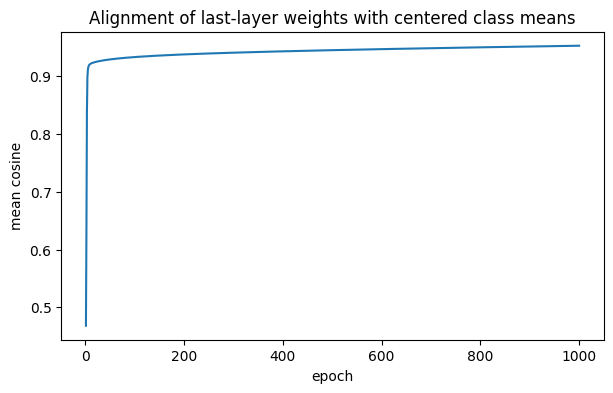

In [8]:
epochs = np.array(history["epoch"])

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["loss"])
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["within_class_variance"])
plt.xlabel("epoch")
plt.ylabel("within-class variance")
plt.title("Within-class feature collapse")
plt.yscale("log")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["alignment_mean_cosine"])
plt.xlabel("epoch")
plt.ylabel("mean cosine")
plt.title("Alignment of last-layer weights with centered class means")
plt.show()

## Inspect the learned feature geometry

In [9]:
final_metrics = nc_metrics(model, X_train, y_train, K)
means = final_metrics["means"]
H = final_metrics["features"]
Y = final_metrics["labels"]

print("Final train accuracy:", accuracy(model, train_loader))
print("Final test accuracy :", accuracy(model, test_loader))
print("Within-class variance:", final_metrics["within_class_variance"])
print("Mean pairwise cosine between centered means:", final_metrics["pairwise_mean_cosine"])
print("Alignment mean cosine:", final_metrics["alignment_mean_cosine"])
print("Per-class alignment cosines:", final_metrics["alignment_per_class"].numpy())

Final train accuracy: 1.0
Final test accuracy : 1.0
Within-class variance: 1.0284960269927979
Mean pairwise cosine between centered means: -0.3329921066761017
Alignment mean cosine: 0.9526764154434204
Per-class alignment cosines: [0.99866796 0.9459687  0.9284803  0.9375886 ]


Since the feature dimension is $d=3$, we can visualize the learned features and class means in 3D.

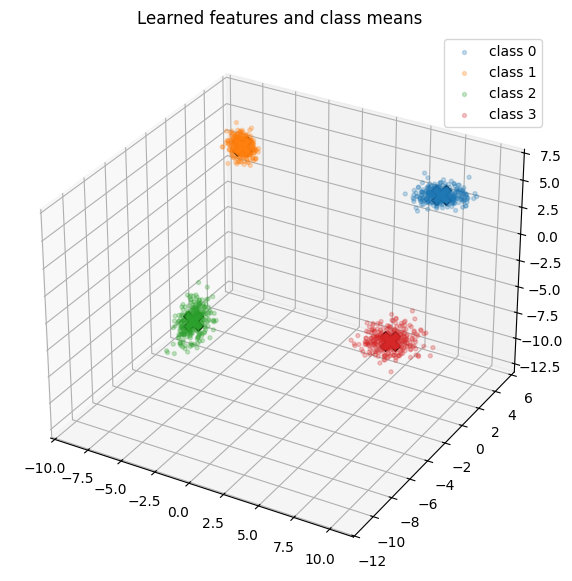

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
for k in range(K):
    Hk = H[Y == k]
    ax.scatter(Hk[:, 0], Hk[:, 1], Hk[:, 2], s=8, alpha=0.25, color=colors[k], label=f"class {k}")
    mk = means[k]
    ax.scatter([mk[0]], [mk[1]], [mk[2]], s=200, marker="X", color=colors[k], edgecolor="black")

ax.set_title("Learned features and class means")
ax.legend()
plt.show()

## Compare centered class means with classifier weights

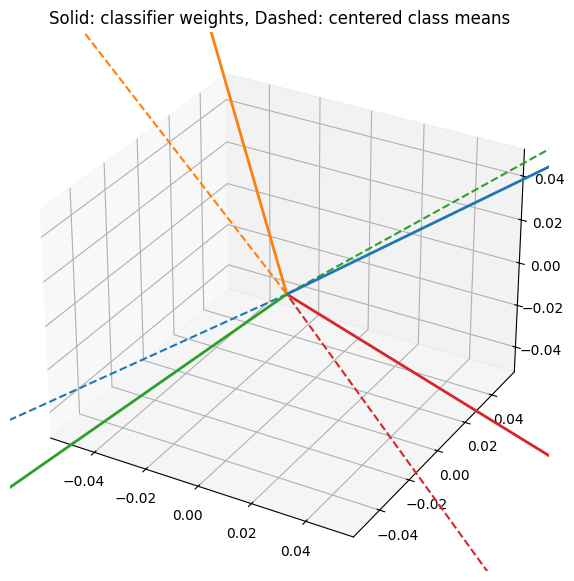

In [11]:
W = final_metrics["W"]
centered_means = final_metrics["centered_means"]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for k in range(K):
    w = W[k].numpy()
    m = centered_means[k].numpy()
    ax.quiver(0, 0, 0, w[0], w[1], w[2], color=colors[k], linewidth=2)
    ax.quiver(0, 0, 0, m[0], m[1], m[2], color=colors[k], linestyle="dashed")

ax.set_title("Solid: classifier weights, Dashed: centered class means")
plt.show()

## Gram matrix of centered class means

For an ideal regular simplex with $K$ classes, the pairwise cosine between distinct normalized class means is

$$
-\frac{1}{K-1}.
$$

For $K=4$, the target value is

$$
-\frac{1}{3} \approx -0.3333.
$$

Target off-diagonal cosine for a simplex ETF: -0.3333333333333333
Observed normalized Gram matrix:
[[ 1.    -0.256 -0.595 -0.147]
 [-0.256  1.    -0.142 -0.643]
 [-0.595 -0.142  1.    -0.216]
 [-0.147 -0.643 -0.216  1.   ]]


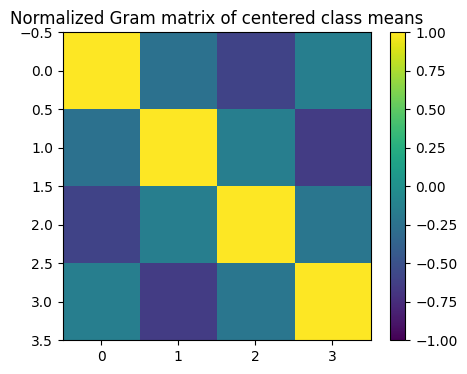

In [12]:
target = -1.0 / (K - 1)
print("Target off-diagonal cosine for a simplex ETF:", target)

gram = final_metrics["gram"].numpy()
print("Observed normalized Gram matrix:")
print(np.round(gram, 3))

plt.figure(figsize=(5, 4))
plt.imshow(gram, vmin=-1, vmax=1)
plt.colorbar()
plt.title("Normalized Gram matrix of centered class means")
plt.show()

## Optional: train longer to emphasize terminal-phase behavior

If you want a sharper collapse effect, try:

- increasing `epochs`
- increasing class separation
- reducing data noise
- using a slightly wider network.

Because this is a tiny synthetic example, the geometry will not be perfectly ideal, but the main trends should be visible.

## Summary

In this notebook we observed a small-scale version of neural collapse:

- **Training accuracy quickly saturates**
- **Within-class feature variance decreases**
- **Class means become more symmetric**
- **Classifier weights align with centered class means**

This makes the example useful as a simple teaching/demo notebook before moving on to larger datasets like CIFAR-10.